# 07 - Stage 2: Severity Score, Labels, and Model

This notebook builds Stage 2 of the two-stage FMD framework.

1. Load DAPH severity dataset
2. Compute severity score
3. Build LOW/MEDIUM/HIGH tertile labels
4. Merge severity labels into model-ready features
5. Train and evaluate Stage 2 classifiers
6. Save artifacts for deployment

In [1]:
from pathlib import Path
import os
import re
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

print(f'XGBoost available: {XGB_AVAILABLE}')

XGBoost available: True


In [2]:
def find_project_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / 'README.md').exists() and (candidate / 'data').exists():
            return candidate
    return start_path.resolve()

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data'
PROC_DIR = DATA_DIR / 'processed'
MODEL_DIR = PROJECT_ROOT / 'models'
PLOT_DIR = PROJECT_ROOT / 'plots' / '07_stage2_severity'

DAPH_FILE = PROC_DIR / 'daph_severity_dataset.xlsx'
FEATURE_FILE = PROC_DIR / 'FMD_model_ready_main refined_final_dataset.csv'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('DAPH file   :', DAPH_FILE)
print('Feature file:', FEATURE_FILE)

if not DAPH_FILE.exists():
    raise FileNotFoundError(f'DAPH file not found: {DAPH_FILE}')
if not FEATURE_FILE.exists():
    raise FileNotFoundError(f'Feature file not found: {FEATURE_FILE}')

Project root: ..
DAPH file   : ..\data\processed\daph_severity_dataset.xlsx
Feature file: ..\data\processed\FMD_model_ready_main refined_final_dataset.csv


In [3]:
def normalize_name(name: str) -> str:
    return re.sub(r'[^a-z0-9]+', '', str(name).strip().lower())

def pick_col(columns, candidates):
    norm_map = {normalize_name(c): c for c in columns}
    for cand in candidates:
        key = normalize_name(cand)
        if key in norm_map:
            return norm_map[key]
    return None

In [4]:
xls = pd.ExcelFile(DAPH_FILE)

print('Sheets:', xls.sheet_names)



preferred_sheet = None

for s in xls.sheet_names:

    if 'daph' in s.lower() or 'severity' in s.lower():

        preferred_sheet = s

        break

if preferred_sheet is None:

    preferred_sheet = xls.sheet_names[0]



# First read with default header; if it looks like a title row, reload with header=1.

daph_raw = pd.read_excel(DAPH_FILE, sheet_name=preferred_sheet)

norm_cols = [normalize_name(c) for c in daph_raw.columns]

unnamed_ratio = sum(str(c).lower().startswith('unnamed') for c in daph_raw.columns) / max(len(daph_raw.columns), 1)

if unnamed_ratio >= 0.5 or 'daphoutbreakseveritydatasetsrilanka20172024' in norm_cols:

    daph_raw = pd.read_excel(DAPH_FILE, sheet_name=preferred_sheet, header=1)



print('Loaded sheet:', preferred_sheet)

print('Raw shape:', daph_raw.shape)

print('Raw columns:', daph_raw.columns.tolist())

Sheets: ['DAPH Data', 'Summary']
Loaded sheet: DAPH Data
Raw shape: (115, 5)
Raw columns: ['District', 'Year', 'Cases', 'Deaths', 'Outbreak Months']


In [5]:
district_col = pick_col(daph_raw.columns, ['district', 'district_name'])
year_col = pick_col(daph_raw.columns, ['year'])
cases_col = pick_col(daph_raw.columns, ['cases', 'no_of_cases', 'case_count'])
deaths_col = pick_col(daph_raw.columns, ['deaths', 'death_count'])
months_col = pick_col(daph_raw.columns, ['outbreak_months', 'months', 'duration_months', 'outbreakdurationmonths'])

required = {
    'District': district_col,
    'Year': year_col,
    'Cases': cases_col,
    'Deaths': deaths_col,
    'Outbreak_Months': months_col
}
missing = [k for k, v in required.items() if v is None]
if missing:
    raise ValueError(f'Missing required columns in DAPH dataset: {missing}')

daph = daph_raw[[district_col, year_col, cases_col, deaths_col, months_col]].copy()
daph.columns = ['District', 'Year', 'Cases', 'Deaths', 'Outbreak_Months']

for c in ['Year', 'Cases', 'Deaths', 'Outbreak_Months']:
    daph[c] = pd.to_numeric(daph[c], errors='coerce')

daph['District'] = daph['District'].astype(str).str.strip().str.title()
daph = daph.dropna(subset=['District', 'Year', 'Cases', 'Deaths', 'Outbreak_Months']).copy()
daph['Year'] = daph['Year'].astype(int)

print('Clean DAPH shape:', daph.shape)
print('Districts:', daph['District'].nunique())
print('Year range:', daph['Year'].min(), 'to', daph['Year'].max())
daph.head()

Clean DAPH shape: (115, 5)
Districts: 23
Year range: 2017 to 2024


,District,Year,Cases,Deaths,Outbreak_Months
0,Kurunegala,2017,5,0,1
1,Batticaloa,2017,14,0,3
2,Ampara,2017,191,2,2
3,Polonnaruwa,2017,52,0,1
4,Anuradhapura,2017,335,0,3


In [6]:
# Severity score formula
daph['severity_score'] = daph['Cases'] * (daph['Outbreak_Months'] / 12.0) + daph['Deaths'] * 10

# Domain-specific thresholds (epidemiologically-informed)
LOW_THRESHOLD = 50
MEDIUM_THRESHOLD = 300

def classify_severity(score):
    if score < LOW_THRESHOLD:
        return 'LOW'
    elif score < MEDIUM_THRESHOLD:
        return 'MEDIUM'
    else:
        return 'HIGH'

daph['severity_class'] = daph['severity_score'].apply(classify_severity)
thresholds = {'LOW_MAX': float(LOW_THRESHOLD), 'MEDIUM_MAX': float(MEDIUM_THRESHOLD)}

print('Severity score summary:')
print(daph['severity_score'].describe().round(3))
print('\nDomain-specific thresholds:')
print(f'LOW < {LOW_THRESHOLD}')
print(f'MEDIUM: {LOW_THRESHOLD} to < {MEDIUM_THRESHOLD}')
print(f'HIGH >= {MEDIUM_THRESHOLD}')
print('\nClass counts:')
print(daph['severity_class'].value_counts())
print('\nBy year:')
print(daph.groupby('Year')['severity_class'].value_counts().unstack(fill_value=0))

Severity score summary:
count     115.000
mean      138.629
std       377.405
min         0.083
25%         3.667
50%        24.167
75%        93.708
max      2997.333
Name: severity_score, dtype: float64

Domain-specific thresholds:
LOW < 50
MEDIUM: 50 to < 300
HIGH >= 300

Class counts:
severity_class
LOW       72
MEDIUM    31
HIGH      12
Name: count, dtype: int64

By year:
severity_class  HIGH  LOW  MEDIUM
Year                             
2017               0   12       2
2018               4    7       5
2019               2    9       7
2020               0   11       4
2021               3    4       6
2022               3   11       5
2023               0    5       2
2024               0   13       0


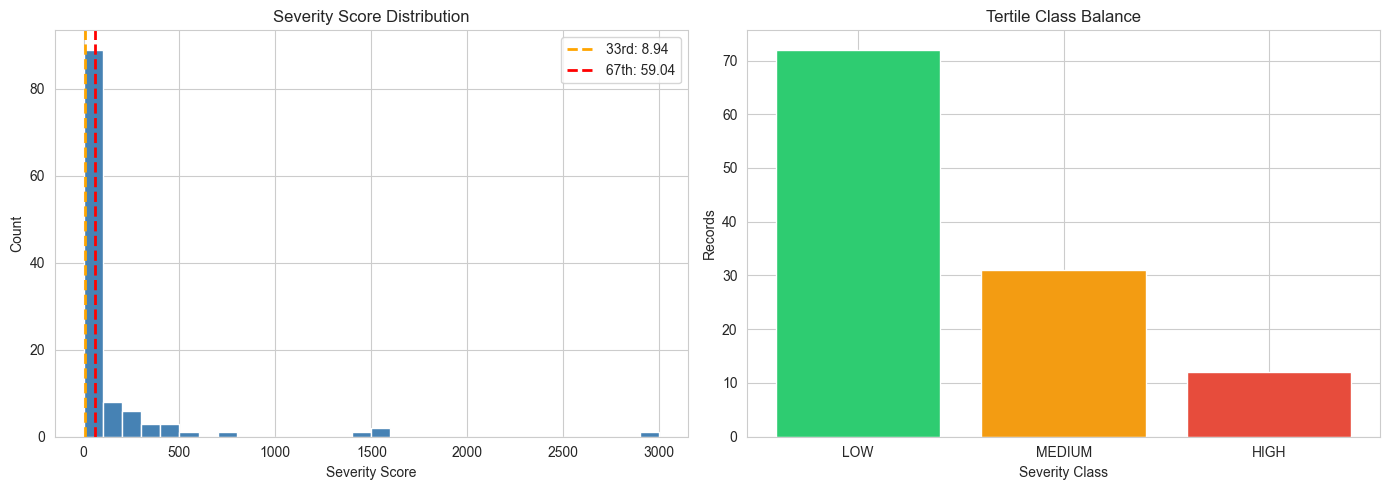

Saved: ..\plots\07_stage2_severity\severity_distribution.png


In [7]:
# Calculate tertiles for reference
t33 = daph['severity_score'].quantile(0.33)
t67 = daph['severity_score'].quantile(0.67)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(daph['severity_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(t33, color='orange', linestyle='--', linewidth=2, label=f'33rd: {t33:.2f}')
axes[0].axvline(t67, color='red', linestyle='--', linewidth=2, label=f'67th: {t67:.2f}')
axes[0].set_title('Severity Score Distribution')
axes[0].set_xlabel('Severity Score')
axes[0].set_ylabel('Count')
axes[0].legend()

order = ['LOW', 'MEDIUM', 'HIGH']
counts = daph['severity_class'].value_counts().reindex(order)
axes[1].bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[1].set_title('Tertile Class Balance')
axes[1].set_xlabel('Severity Class')
axes[1].set_ylabel('Records')

plt.tight_layout()
plot_path = PLOT_DIR / 'severity_distribution.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', plot_path)

In [8]:
feat = pd.read_csv(FEATURE_FILE)
print('Feature shape:', feat.shape)
print('Feature columns:', feat.columns.tolist())

Feature shape: (2400, 26)
Feature columns: ['year', 'month_num', 'district', 'PCODE', 'sin_month', 'cos_month', 'monsoon_phase_First_Inter_Monsoon', 'monsoon_phase_SW_Monsoon', 'monsoon_phase_Second_Inter_Monsoon', 'monsoon_phase_NE_Monsoon', 'rainfall_mm', 'r3h', 'rfq', 'rain_lag1', 'rain_lag2', 'rfq_lag1', 'Outbreak status', 'lat', 'lon', 'humidity', 'wind_speed', 'temp_lag1', 'humidity_lag1', 'wind_lag1', 'buffalo_density', 'livestock_density']


In [9]:
district_f_col = pick_col(feat.columns, ['district'])
year_f_col = pick_col(feat.columns, ['year'])
month_f_col = pick_col(feat.columns, ['month_num', 'month'])
target_f_col = pick_col(feat.columns, ['Outbreak status', 'outbreak_status'])

required_feat = {
    'district': district_f_col,
    'year': year_f_col,
    'month_num': month_f_col,
    'Outbreak status': target_f_col
}
missing_feat = [k for k, v in required_feat.items() if v is None]
if missing_feat:
    raise ValueError(f'Missing required feature columns: {missing_feat}')

feat = feat.copy()
feat[district_f_col] = feat[district_f_col].astype(str).str.strip().str.title()
feat[year_f_col] = pd.to_numeric(feat[year_f_col], errors='coerce')
feat[target_f_col] = pd.to_numeric(feat[target_f_col], errors='coerce').fillna(0).astype(int)

severity_lookup = daph[['District', 'Year', 'severity_score', 'severity_class']].copy()

merged = feat.merge(
    severity_lookup,
    left_on=[district_f_col, year_f_col],
    right_on=['District', 'Year'],
    how='left'
)

outbreak_df = merged[merged[target_f_col] == 1].copy()
outbreak_df = outbreak_df.dropna(subset=['severity_class']).copy()

print('All feature rows:', len(merged))
print('Outbreak rows:', (merged[target_f_col] == 1).sum())
print('Outbreak rows with severity class:', len(outbreak_df))
print('\nSeverity class distribution in outbreak subset:')
print(outbreak_df['severity_class'].value_counts())

unmatched = merged[(merged[target_f_col] == 1) & (merged['severity_class'].isna())][[district_f_col, year_f_col]].drop_duplicates()
if len(unmatched) > 0:
    print('\nUnmatched outbreak district-year combinations:')
    print(unmatched.head(20))
else:
    print('\nAll outbreak rows matched to severity labels.')

All feature rows: 2400
Outbreak rows: 306
Outbreak rows with severity class: 306

Severity class distribution in outbreak subset:
severity_class
LOW       172
MEDIUM     94
HIGH       40
Name: count, dtype: int64

All outbreak rows matched to severity labels.


In [10]:
LABELS = ['LOW', 'MEDIUM', 'HIGH']

class_to_int = {label: i for i, label in enumerate(LABELS)}

int_to_class = {i: label for label, i in class_to_int.items()}



outbreak_df['severity_encoded'] = outbreak_df['severity_class'].map(class_to_int)

if outbreak_df['severity_encoded'].isna().any():

    raise ValueError('Unexpected severity class found outside LOW/MEDIUM/HIGH.')

outbreak_df['severity_encoded'] = outbreak_df['severity_encoded'].astype(int)



drop_cols = {

    district_f_col, year_f_col, month_f_col, target_f_col,

    'District', 'Year', 'severity_score', 'severity_class', 'severity_encoded'

}



candidate_cols = [c for c in outbreak_df.columns if c not in drop_cols]

numeric_cols = outbreak_df[candidate_cols].select_dtypes(include=[np.number, 'bool']).columns.tolist()

FEATURE_COLS = [c for c in numeric_cols if c not in ['Cases', 'Deaths', 'Outbreak_Months']]



print('Feature count:', len(FEATURE_COLS))

print(FEATURE_COLS)

print('Label mapping:', class_to_int)

Feature count: 21
['sin_month', 'cos_month', 'monsoon_phase_First_Inter_Monsoon', 'monsoon_phase_SW_Monsoon', 'monsoon_phase_Second_Inter_Monsoon', 'monsoon_phase_NE_Monsoon', 'rainfall_mm', 'r3h', 'rfq', 'rain_lag1', 'rain_lag2', 'rfq_lag1', 'lat', 'lon', 'humidity', 'wind_speed', 'temp_lag1', 'humidity_lag1', 'wind_lag1', 'buffalo_density', 'livestock_density']
Label mapping: {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}


In [11]:
# Leave-One-Year-Out validation on years with mixed severity classes
valid_test_years = [2018, 2019, 2021, 2022]  # Years with HIGH, MEDIUM, and LOW cases

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42
    )
}

if XGB_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42
    )

results = []

print('=' * 60)
print('LOYO VALIDATION RESULTS (2018, 2019, 2021, 2022 as test years)')
print('=' * 60)

for model_name, model in models.items():
    loyo_f1s = []
    print(f'\n{model_name}')
    print('-' * 50)

    for test_year in valid_test_years:
        train_mask = outbreak_df[year_f_col] != test_year
        test_mask = outbreak_df[year_f_col] == test_year

        train = outbreak_df[train_mask]
        test = outbreak_df[test_mask]

        if train.empty or test.empty:
            print(f'Year {test_year}: skipped (empty fold).')
            continue

        # Check if test set has multiple classes
        if test['severity_class'].nunique() < 2:
            print(f'Year {test_year}: skipped (only 1 class in test).')
            continue

        X_train = train[FEATURE_COLS].fillna(0)
        y_train = train['severity_encoded']
        X_test = test[FEATURE_COLS].fillna(0)
        y_test = test['severity_encoded']

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        loyo_f1s.append(f1)

        print(f'Year {test_year}: Accuracy={acc:.3f}, MacroF1={f1:.3f} | Classes: {test["severity_class"].value_counts().to_dict()}')

    if loyo_f1s:
        results.append({
            'Model': model_name,
            'Mean Accuracy': float(np.mean(loyo_f1s)),
            'Mean Macro F1': float(np.mean(loyo_f1s))
        })

print('\n' + '=' * 60)
results_df = pd.DataFrame(results).sort_values('Mean Macro F1', ascending=False)
display(results_df)

LOYO VALIDATION RESULTS (2018, 2019, 2021, 2022 as test years)

Random Forest
--------------------------------------------------
Year 2018: Accuracy=0.438, MacroF1=0.428 | Classes: {'HIGH': 19, 'MEDIUM': 18, 'LOW': 11}
Year 2019: Accuracy=0.378, MacroF1=0.389 | Classes: {'MEDIUM': 21, 'LOW': 16, 'HIGH': 8}
Year 2021: Accuracy=0.323, MacroF1=0.244 | Classes: {'MEDIUM': 18, 'LOW': 7, 'HIGH': 6}
Year 2022: Accuracy=0.722, MacroF1=0.532 | Classes: {'LOW': 16, 'MEDIUM': 13, 'HIGH': 7}

XGBoost
--------------------------------------------------
Year 2018: Accuracy=0.375, MacroF1=0.372 | Classes: {'HIGH': 19, 'MEDIUM': 18, 'LOW': 11}
Year 2019: Accuracy=0.356, MacroF1=0.345 | Classes: {'MEDIUM': 21, 'LOW': 16, 'HIGH': 8}
Year 2021: Accuracy=0.484, MacroF1=0.356 | Classes: {'MEDIUM': 18, 'LOW': 7, 'HIGH': 6}
Year 2022: Accuracy=0.639, MacroF1=0.466 | Classes: {'LOW': 16, 'MEDIUM': 13, 'HIGH': 7}



,Model,Mean Accuracy,Mean Macro F1
0,Random Forest,0.398307,0.398307
1,XGBoost,0.384745,0.384745


In [12]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print('Best model:', best_model_name)

# Train final model on all data except 2024
train_final = outbreak_df[outbreak_df[year_f_col] < 2024].copy()
test_2024 = outbreak_df[outbreak_df[year_f_col] == 2024].copy()

X_train_f = train_final[FEATURE_COLS].fillna(0)
y_train_f = train_final['severity_encoded']
X_test_2024 = test_2024[FEATURE_COLS].fillna(0)
y_test_2024 = test_2024['severity_encoded']

best_model.fit(X_train_f, y_train_f)
y_pred_2024 = best_model.predict(X_test_2024)

print('\n' + '=' * 60)
print('2024 PREDICTIONS (using model trained on 2017-2023)')
print('=' * 60)
print(f'Predicted class distribution:')
print(pd.Series([LABELS[i] for i in y_pred_2024]).value_counts())
print(f'\nNote: 2024 was a LOW severity year -- minimal HIGH/MEDIUM cases expected')

Best model: Random Forest

2024 PREDICTIONS (using model trained on 2017-2023)
Predicted class distribution:
LOW       45
MEDIUM    26
HIGH       7
Name: count, dtype: int64

Note: 2024 was a LOW severity year -- minimal HIGH/MEDIUM cases expected


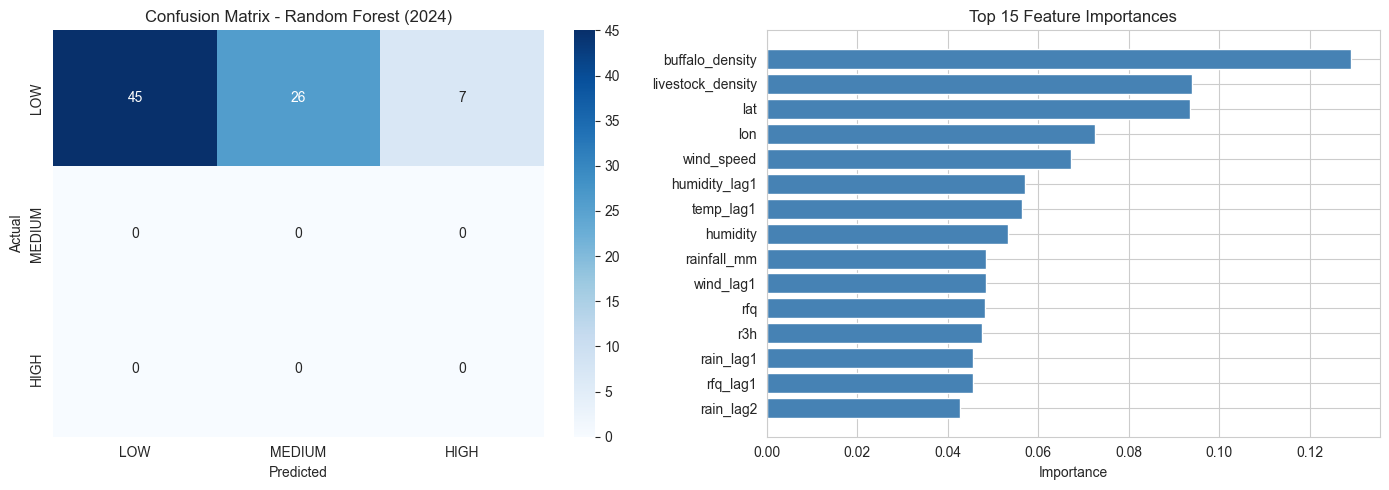

Saved: ..\plots\07_stage2_severity\stage2_model_evaluation.png


In [13]:
cm = confusion_matrix(y_test_2024, y_pred_2024, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS, ax=axes[0])
axes[0].set_title(f'Confusion Matrix - {best_model_name} (2024)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    top = importances.sort_values(ascending=False).head(15).sort_values()
    axes[1].barh(top.index, top.values, color='steelblue')
    axes[1].set_title('Top 15 Feature Importances')
    axes[1].set_xlabel('Importance')
else:
    axes[1].axis('off')
    axes[1].text(0.1, 0.5, 'Feature importance not available', fontsize=11)

plt.tight_layout()
eval_plot = PLOT_DIR / 'stage2_model_evaluation.png'
plt.savefig(eval_plot, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', eval_plot)

In [14]:
# Retrain final model on all outbreak data except 2024 for deployment
print('\nRetraining final model on all years 2017-2023...')
X_final = train_final[FEATURE_COLS].fillna(0)
y_final = train_final['severity_encoded']
best_model.fit(X_final, y_final)

# Save final model with standardized name
joblib.dump(best_model, MODEL_DIR / 'stage2_rf_model.pkl')
joblib.dump(class_to_int, MODEL_DIR / 'stage2_label_encoder.pkl')
joblib.dump(thresholds, MODEL_DIR / 'severity_thresholds.pkl')
joblib.dump(FEATURE_COLS, MODEL_DIR / 'stage2_feature_cols.pkl')

print('\nArtifacts saved:')
for fname in [
    'stage2_rf_model.pkl',
    'stage2_label_encoder.pkl',
    'severity_thresholds.pkl',
    'stage2_feature_cols.pkl'
]:
    fpath = MODEL_DIR / fname
    if fpath.exists():
        print(f'  OK {fname} ({fpath.stat().st_size/1024:.1f} KB)')
    else:
        print(f'  ERROR {fname} (NOT FOUND)')


Retraining final model on all years 2017-2023...

Artifacts saved:
  OK stage2_rf_model.pkl (1528.5 KB)
  OK stage2_label_encoder.pkl (0.0 KB)
  OK severity_thresholds.pkl (0.1 KB)
  OK stage2_feature_cols.pkl (0.3 KB)


In [15]:
severity_export = daph[['District', 'Year', 'Cases', 'Deaths', 'Outbreak_Months', 'severity_score', 'severity_class']].copy()
export_path = PROC_DIR / 'severity_labels.csv'
severity_export.to_csv(export_path, index=False)
print('Saved:', export_path)
print('Export shape:', severity_export.shape)
severity_export.head(10)

Saved: ..\data\processed\severity_labels.csv
Export shape: (115, 7)


,District,Year,Cases,Deaths,Outbreak_Months,severity_score,severity_class
0,Kurunegala,2017,5,0,1,0.416667,LOW
1,Batticaloa,2017,14,0,3,3.500000,LOW
2,Ampara,2017,191,2,2,51.833333,MEDIUM
3,Polonnaruwa,2017,52,0,1,4.333333,LOW
4,Anuradhapura,2017,335,0,3,83.750000,MEDIUM
5,Badulla,2017,35,4,3,48.750000,LOW
6,Monaragala,2017,15,0,1,1.250000,LOW
7,Gampaha,2017,3,1,1,10.250000,LOW
8,Kandy,2017,1,0,1,0.083333,LOW
9,Hambantota,2017,19,2,3,24.750000,LOW


## Summary

- Stage 2 input severity dataset: data/processed/daph_severity_dataset.xlsx
- Formula: Cases x (Outbreak_Months / 12) + Deaths x 10
- Labels: tertile-based LOW, MEDIUM, HIGH
- Training subset: outbreak rows only
- Validation: forward-chaining with 2022, 2023, 2024 test years
- Saved artifacts: model, encoder, thresholds, feature list